# Machine Learning with Qiskit

In [ ]:
pip install qiskit

In [1]:
pip install pylatexenc

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [3]:
import numpy as np
import matplotlib.pyplot as plt


In [4]:
def generate_waveline(num_points): 
  x = np.linspace(0.5, 0.5+ 2* np.pi, num_points)
  y = 0.3* np.sin(x)+ 0.4 *np.sin(2*x) -0.2* np.sin(0.5 * x) 
  return x.reshape((-1,1)), y

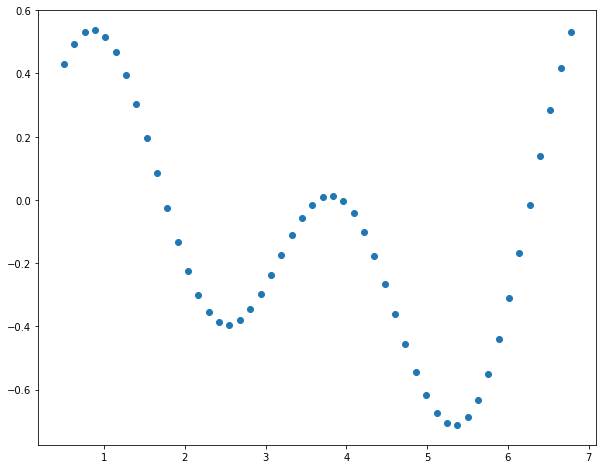

In [5]:
X, y =  generate_waveline(50)
plt.figure(figsize=(10, 8)) 
plt.plot(X, y.real, "o")

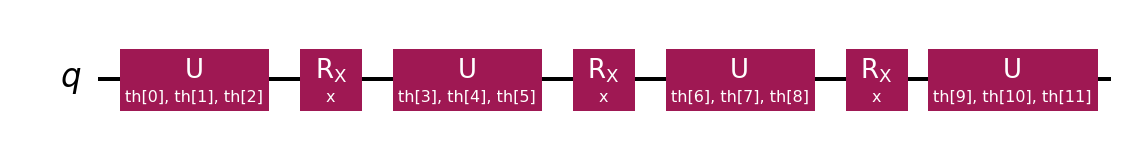

In [6]:
from qiskit.circuit import Parameter, ParameterVector
from qiskit import transpile, BasicAer,  QuantumCircuit
reps = 3
circuit = QuantumCircuit(1)
x= Parameter("x")
theta = ParameterVector ("th", 3 *(reps + 1))

for i in range(reps): 
  circuit.u(theta[3*i], theta[3*i+1], theta[3*i+2], 0) 
  circuit.rx(x, 0)

circuit.u(*theta[-3:], 0)

circuit.draw("mpl", style="iqx", scale=2)

In [7]:
from qiskit_machine_learning.neural_networks import OpflowQNN 
from qiskit.opflow import Z, StateFn
expectation= StateFn(Z, is_measurement=True) @ StateFn(circuit)
qnn =OpflowQNN(expectation, input_params=[x], weight_params=list(theta), quantum_instance=BasicAer.get_backend("statevector_simulator"))

In [10]:
from qiskit.algorithms.optimizers import COBYLA

from qiskit_machine_learning.algorithms import NeuralNetworkRegressor
loss_history = [] 
def store_loss(weights, loss_value): 
    loss_history.append(loss_value)
    
regressor= NeuralNetworkRegressor(neural_network=qnn, optimizer=COBYLA(), loss="squared_error", callback=store_loss)

In [11]:
regressor.fit(X,y)

In [12]:
y_hat = regressor.predict(X)

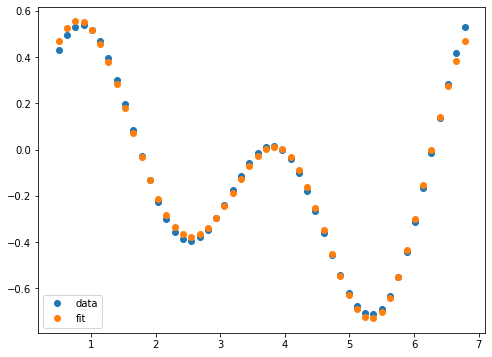

In [14]:
plt.figure(figsize=(8,6))
plt.plot(X,y, "o",label="data")
plt.plot(X,y_hat,"o",label="fit")
plt.legend(loc="best")

Text(0.5, 0, 'function evaluations')

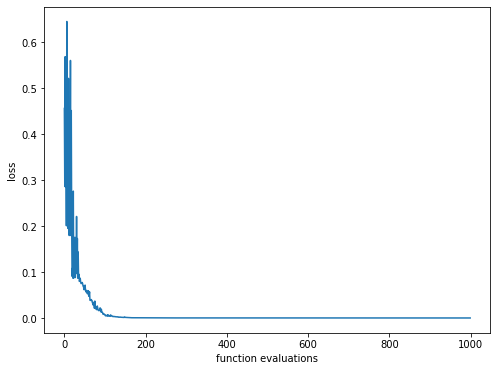

In [15]:
plt.figure(figsize=(8,6))
plt.plot(loss_history)
plt.ylabel("loss")
plt.xlabel("function evaluations")

In [17]:
# Select dataset dimension (num_inputs) and size (num_samples)
num_inputs = 2
num_samples = 20

# Generate random input coordinates (X) and bin ary_labels (y)
X = 2*np.random.random([num_samples,num_inputs])-1
y01 = 1* (np.sum(X ,axis=1)>= 8) # in (0,1) y01 will be used for CircuitQNN example
y = 2* y01 -1 # in {-1,1} y will be used in oplowQNN example

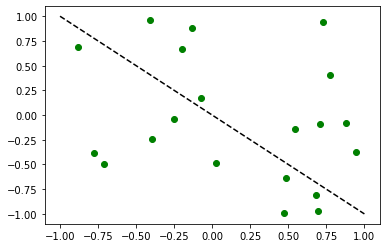

In [21]:
from torch import Tensor
# Convert to torch Tensors
X_ = Tensor(X)
y01_= Tensor(y01).reshape(len(y)).long()
y_= Tensor(y).reshape(len(y), 1)
# Plot dataset
for x, y_target in zip(X, y):
    if y_target == 1: 
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go") 

plt.plot([-1, 1], [1, -1], "--", color="black")

In [24]:
from qiskit_machine_learning.neural_networks import TwoLayerQNN 
from qiskit_machine_learning.connectors import TorchConnector
qnn = TwoLayerQNN(num_qubits=num_inputs, quantum_instance=BasicAer.get_backend("statevector_simulator"))

# Set up PyTorch module
initial_weights = 0.1*(2*np.random.random(qnn.num_weights) - 1)
model = TorchConnector(qnn, initial_weights = initial_weights)
print("Initial weights: ", initial_weights)

Initial weights:  [ 0.08020809 -0.01040323 -0.08391015 -0.03664712 -0.09865321  0.04261465
  0.01977591  0.00108476]


In [26]:
from torch.nn import MSELoss
from torch.optim import LBFGS

# Define optimizer and loss
optimizer = LBFGS(model.parameters()) 
f_loss = MSELoss(reduction="sum")

#Start training
model.train() # set model to training mode

TorchConnector()

the following code took 12 min to be executed

In [29]:
def closure():
    optimizer.zero_grad() # Initialize/clear gradients 
    loss = f_loss(model(X_), y_) # Evaluate loss function
    loss.backward() # Backward pass
    return loss


for _ in range(100): 
    optimizer.step(closure)